In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from plotnine import *
from datetime import datetime, date, timedelta, time

In [114]:
# https://nbviewer.org/github/mayabenowitz/Hedgecraft/blob/master/notebooks/Hedgecraft.ipynb

In [115]:
import pandas as pd
import numpy as np

#silence warnings
import warnings
warnings.filterwarnings("ignore")

#reads the csv file into pandas DataFrame
BASE_DATA_DIR = "D:/Code/tgraphportfolio/rsrc/data/eod"

df2 = pd.read_csv(f"{BASE_DATA_DIR}/all_stocks_2006-01-01_to_2018-01-01.csv")
df = pd.read_csv(f"{BASE_DATA_DIR}/FTSE100_20070102_20190211.csv")

In [116]:
df['Date'] = pd.to_datetime(df['Index'])

In [117]:

#imports the dcor module to calculate distance correlation
import dcor

#function to compute the distance correlation (dcor) matrix from a DataFrame and output a DataFrame 
#of dcor values.
def df_distance_correlation(df_train, stocks):
    #initializes an empty DataFrame
    df_train_dcor = pd.DataFrame(index=stocks, columns=stocks)
    #initialzes a counter at zero
    k=0
    #iterates over the time series of each stock
    for i in stocks:
        #stores the ith time series as a vector
        v_i = df_train.loc[:, i].values
        #iterates over the time series of each stock subect to the counter k
        for j in stocks[k:]: # only does what it needs to (k:)
            #stores the jth time series as a vector
            v_j = df_train.loc[:, j].values
            
            vi_vj = np.column_stack((v_i,v_j))
            vi_vj = vi_vj[~np.isnan(vi_vj).any(axis=1)]

            #computes the dcor coefficient between the ith and jth vectors
            dcor_val = dcor.distance_correlation(vi_vj[:,0], vi_vj[:,1])            #appends the dcor value at every ij entry of the empty DataFrame
            df_train_dcor.at[i,j] = dcor_val
            #appends the dcor value at every ji entry of the empty DataFrame
            df_train_dcor.at[j,i] = dcor_val
        #increments counter by 1
        k+=1    
    #returns a DataFrame of dcor values for every pair of stocks
    return df_train_dcor

In [126]:
# dff will be the df2
dff = df2[:]
dff['Date'] = pd.to_datetime(dff['Date']).dt.date


In [127]:
(dff['Date'].min(),dff['Date'].max())

(datetime.date(2006, 1, 3), datetime.date(2017, 12, 29))

In [ ]:
#creates a DataFrame for each time-series (see In [11])
cutoff_date = date(2012, 1, 1)
df_train = dff.query("Date < @cutoff_date")
df_train = df_train.dropna()
df_train['IntraDelta'] = df_train['Close'] - df_train['Open']

In [134]:
def pivot_to_wide_format(df, date_col='Date', name_col='Name', value_col='Close'):
    """
    Pivot a dataframe from long to wide format.
    
    Parameters:
    -----------
    df : DataFrame
        Input dataframe with Date, Name, and value columns
    date_col : str, default 'Date'
        Name of the date column
    name_col : str, default 'Name'
        Name of the column containing names to become column headers
    value_col : str, default 'Close'
        Name of the column containing values to pivot
    
    Returns:
    --------
    DataFrame
        Pivoted dataframe with Date as rows, Name values as columns, sorted alphabetically
    """
    # Pivot to wide format: Date as rows, Name as columns, values as specified
    df_pivoted = df.pivot(index=date_col, columns=name_col, values=value_col)
    # Sort column names (Name values) alphabetically
    df_pivoted = df_pivoted.reindex(sorted(df_pivoted.columns), axis=1)
    # Reset index to make Date a column
    df_pivoted = df_pivoted.reset_index()
    return df_pivoted

# Apply the function to df_train
df_train_close = pivot_to_wide_format(df_train, value_col='Close')
df_train_open = pivot_to_wide_format(df_train, value_col='Open')
df_train_high = pivot_to_wide_format(df_train, value_col='High')
df_train_low = pivot_to_wide_format(df_train, value_col='Low')
df_train_intradelta = pivot_to_wide_format(df_train, value_col='IntraDelta')

#makes a copy of the traning dataset
# df_train_close_copy = df_train_close.copy()

In [135]:
df_train_high_dcor = df_distance_correlation( df_train_high, stocks = [x for x in df_train_high.columns if x!='Date'] )
df_train_low_dcor = df_distance_correlation( df_train_low, stocks = [x for x in df_train_low.columns if x!='Date'] )
df_train_open_dcor = df_distance_correlation( df_train_open, stocks = [x for x in df_train_open.columns if x!='Date'] )
df_train_close_dcor = df_distance_correlation( df_train_close, stocks = [x for x in df_train_close.columns if x!='Date'] )
df_train_intradelta_dcor = df_distance_correlation( df_train_intradelta, stocks = [x for x in df_train_intradelta.columns if x!='Date'] )

In [140]:
#imports the NetworkX module
import networkx as nx

# takes in a pre-processed dataframe and returns a time-series correlation
# network with pairwise distance correlation values as the edges
def build_corr_nx(df_train):
    # converts the distance correlation dataframe to a numpy matrix with dtype float
    cor_matrix = df_train.values.astype('float')
    # Since dcor ranges between 0 and 1, (0 corresponding to independence and 1
    # corresponding to dependence), 1 - cor_matrix results in values closer to 0
    # indicating a higher degree of dependence where values close to 1 indicate a lower degree of 
    # dependence. This will result in a network with nodes in close proximity reflecting the similarity
    # of their respective time-series and vice versa.
    sim_matrix = 1 - cor_matrix
    # transforms the similarity matrix into a graph
    G = nx.from_numpy_array(sim_matrix)
    # extracts the indices (i.e., the stock names from the dataframe)
    stock_names = df_train.index.values
    # relabels the nodes of the network with the stock names
    G = nx.relabel_nodes(G, lambda x: stock_names[x])
    # assigns the edges of the network weights (i.e., the dcor values)
    G.edges(data=True)
    # copies G
    ## we need this to delete edges or othwerwise modify G
    H = G.copy()
    # iterates over the edges of H (the u-v pairs) and the weights (wt)
    for (u, v, wt) in G.edges.data('weight'):
        # selects edges with dcor values less than or equal to 0.33
        if wt >= 1 - 0.325:
            # removes the edges 
            H.remove_edge(u, v)
        # selects self-edges
        if u == v:
            # removes the self-edges
            H.remove_edge(u, v)
    # returns the final stock correlation network            
    return H

In [141]:
# df_train_high_dcor

In [146]:
H_close = build_corr_nx(df_train_close_dcor)
H_open = build_corr_nx(df_train_open_dcor)
H_close_diff = build_corr_nx(df_train_intradelta_dcor)
H_high = build_corr_nx(df_train_high_dcor)
H_low = build_corr_nx(df_train_low_dcor)

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

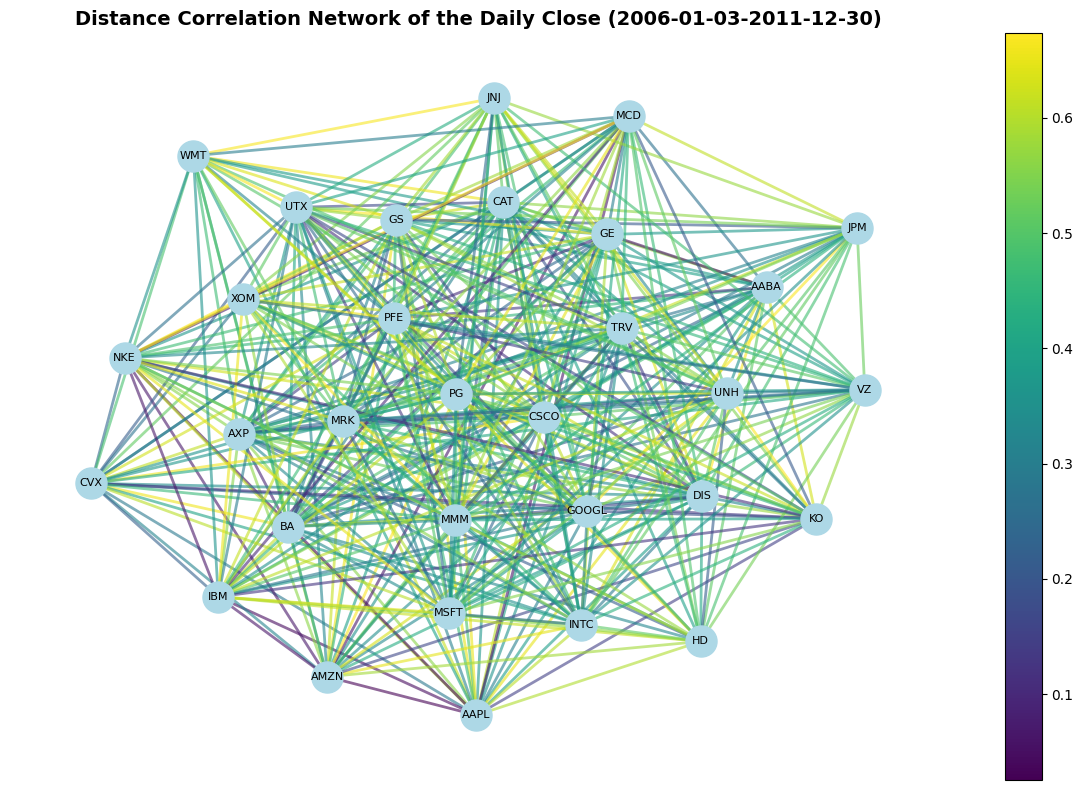

In [160]:
# def plot_corr_nx_w_title(H, df_train, type = "Close"):
#     title_str = f"Distance Correlation Network of the Daily {type} ({df_train['Date'].min().strftime('%Y-%m-%d')}-{df_train['Date'].max().strftime('%Y-%m-%d')})"
#     plt_corr_nx(H, title=title_str)

plot_corr_nx_w_title(H_close, df_train_close, 'Close')

In [200]:
import gravis as gv
import matplotlib.pyplot as plt

def plot_corr_gravis(H):
    """
    Plot a networkx graph using gravis with edge colors based on weights.
    
    Parameters:
    -----------
    H : networkx.Graph
        Graph to plot
    """
    # Get edge weights for color mapping
    weights = [H[u][v]['weight'] for u, v in H.edges()]
    min_weight = min(weights)
    max_weight = max(weights)
    
    # Normalize weights to 0-1 range for color mapping
    def normalize_weight(w):
        if max_weight == min_weight:
            return 0.5
        return (w - min_weight) / (max_weight - min_weight)
    
    # Create a copy of the graph with normalized weights and colors
    G = H.copy()
    
    # Add color attributes to edges based on normalized weights
    # Using viridis-like color scheme (blue to yellow)
    for u, v in G.edges():
        weight = G[u][v]['weight']
        norm_weight = normalize_weight(weight)
        
        # Convert normalized weight to RGB color (viridis-like: blue to yellow)
        # Using a simple color interpolation
        if norm_weight < 0.5:
            # Blue to cyan
            r = 0
            g = int(norm_weight * 2 * 255)
            b = 255
        else:
            # Cyan to yellow
            r = int((norm_weight - 0.5) * 2 * 255)
            g = 255
            b = int(255 - (norm_weight - 0.5) * 2 * 255)
        
        # Convert to hex color
        color = f"#{r:02x}{g:02x}{b:02x}"
        G[u][v]['color'] = color
        G[u][v]['width'] = 2 + norm_weight * 3  # Width based on weight
    
    # Set node attributes
    for node in G.nodes():
        G.nodes[node]['size'] = 20
        G.nodes[node]['color'] = '#ADD8E6'  # lightblue
    
    # Create visualization with gravis
    fig = gv.d3(
        G,
        graph_height=400,
        details_height=400,
        show_details=True,
        show_details_toggle_button=True,
        show_menu=True,
        show_menu_toggle_button=True,
        show_node=True,        
        # title=title,
        show_edge_label=False,
        show_node_label=True,
        # node_label_size=12,
        node_hover_neighborhood=True,
        node_hover_tooltip=True,
        show_node_image=True,
        show_edge=True,
        edge_size_factor=1.0,
        edge_size_data_source='size',
        use_edge_size_normalization=False,
        edge_size_normalization_min=0.2,
        edge_size_normalization_max=5.0,
        edge_curvature=0.0,
        edge_hover_tooltip=True,            
        # edge_width_data_source='width',
        # edge_color_data_source='color',
        # node_size_data_source='size',
        # node_color_data_source='color',
        use_node_size_normalization=False,
        # use_edge_size_normalization=False,
        # height=800,
        # width=1200
    )
    
    return fig

def plot_corr_gravis_w_title(H, df_train, type="Close"):
    """
    Plot correlation network with gravis, including date range in title.
    
    Parameters:
    -----------
    H : networkx.Graph
        Graph to plot
    df_train : DataFrame
        DataFrame with 'Date' column
    type : str, default "Close"
        Type of data being plotted (for title)
    """
    # Get min and max dates, handling both datetime.date and string formats
    min_date = df_train['Date'].min()
    max_date = df_train['Date'].max()
    
    # Format dates - handle both datetime.date and string types
    if isinstance(min_date, str):
        min_date_str = min_date
    else:
        min_date_str = min_date.strftime('%Y-%m-%d')
    
    if isinstance(max_date, str):
        max_date_str = max_date
    else:
        max_date_str = max_date.strftime('%Y-%m-%d')
    
    title_str = f"Distance Correlation Network of the Daily {type} ({min_date_str}-{max_date_str})"
    return plt_corr_gravis(H, title=title_str)

In [201]:
plot_corr_gravis(H_close)